## Space Detection

### Purpose

Space objects are used as the **foundation of the building topology**.  
They allow the system to understand where doors, exit signs, and other elements are located within the floor plan.

Later in the pipeline, these spaces are used to:

- Determine which **rooms or corridors a door connects**
- Detect **external doors**
- Associate **exit signs with specific spaces**
- Build a **navigation graph for route calculation**

### Detection Filtering

Each space class has its own confidence threshold, the YOLO model runs with a lower global confidence, and filtering is performed afterward to ensure that only reliable detections are stored as `Space`, `Door` or `Sign` objects.

### Data stored in a Space object

Each object contains:

- **id** – unique identifier within the floor plan
- **class_name** – detected space type
- **confidence** – YOLO detection confidence
- **bbox** – bounding box `(x1, y1, x2, y2)`
- **polygon** – simplified polygon representing the detected area

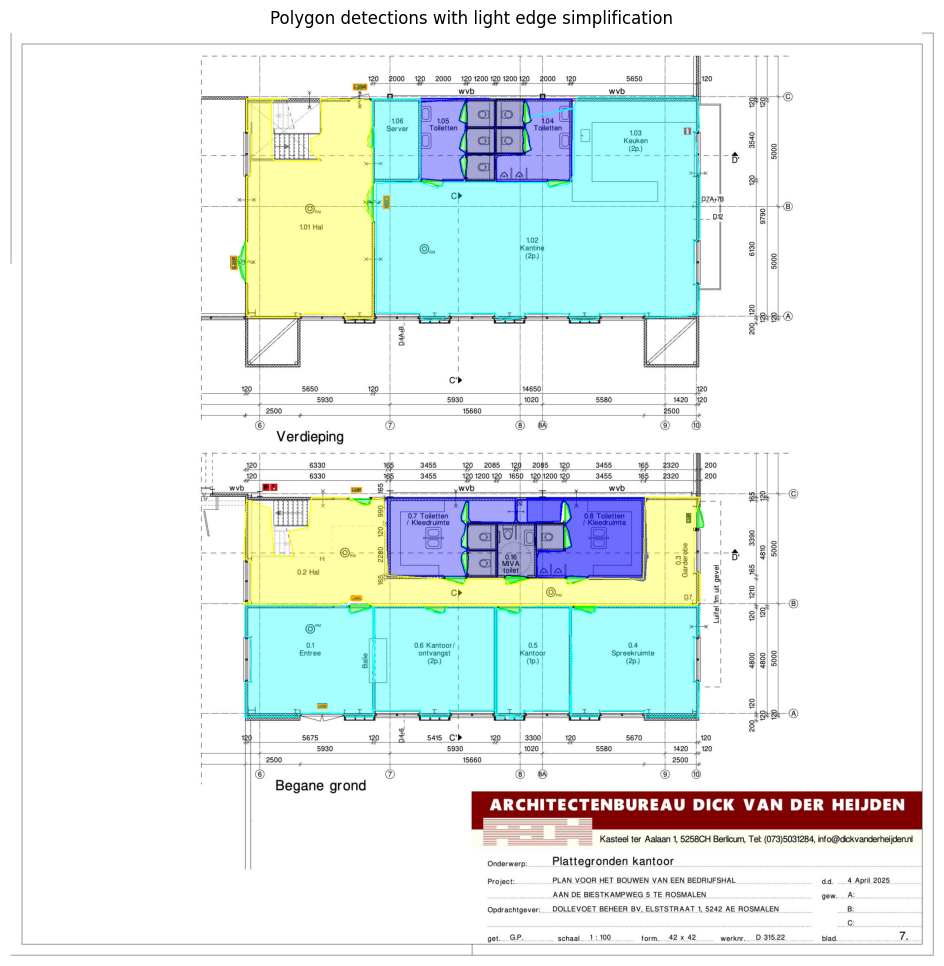

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path
from src.geometry import simplify_polygon
from src.topology import assign_spaces_to_doors
from src.models import DetectionObject, Space, Door, Sign

# Minimum confidence for objects that are not explicitly defined in class thresholds
global_confidence = 0.25

# Confidence used for the YOLO model itself
model_confidence = 0.1

# Detection thresholds per class
SPACE_CLASSES = {'room' : 0.4, 'bathroom': 0.4, 'toilets': 0.4, 'corridor': 0.25, 'Elevator': 0.25}
DOOR_CLASSES = {'door' : 0.4}
SIGN_CLASSES = {'exit': 0.6}

# Combine all allowed classes for easy checking
ALLOWED_CLASSES = SPACE_CLASSES | DOOR_CLASSES | SIGN_CLASSES

# Path to the YOLO model
model = YOLO("/mnt/c/datasets/enginize/seg_training_run/best.pt")
# Path to the floorplan image
image_path = Path("/mnt/c/datasets/enginize/floorplan_seg/train/images/kantoor.jpg")

if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path.resolve()}")

# Run the model on the image with specified confidence and mask options
result = model.predict(str(image_path), conf=model_confidence, retina_masks=True, verbose=False)[0]
if result.masks is None:
    raise ValueError("No segmentation masks found.")

spaces = []
doors = []
signs = []
other_items = []

# Process each detected box and its corresponding mask
for i, box in enumerate(result.boxes):
    class_id = int(box.cls.item())
    class_name = model.names[class_id]

    # Skip classes that are not in our defined thresholds
    if class_name not in ALLOWED_CLASSES:
        continue

    confidence = float(box.conf.item())
    x1, y1, x2, y2 = map(int, box.xyxy.squeeze())

    poly = result.masks.xy[i]
    polygon = [(int(x), int(y)) for x, y in poly]

    # Skip polygons that are too small to be meaningful
    if len(polygon) < 3:
        continue

    polygon = simplify_polygon(polygon, epsilon_ratio=0.002)

    # Create objects based on class and confidence thresholds
    if class_name in SPACE_CLASSES and confidence >= SPACE_CLASSES[class_name]:
        space = Space(
            id=len(spaces), 
            class_name=class_name, 
            confidence=confidence, 
            bbox=(x1, y1, x2, y2), 
            polygon=polygon
        )
        spaces.append(space)

    elif class_name in DOOR_CLASSES and confidence >= DOOR_CLASSES[class_name]:
        door = Door(
            id=len(doors),
            class_name=class_name,
            confidence=confidence,
            bbox=(x1, y1, x2, y2),
            polygon=polygon,
            center=((x1 + x2) // 2, (y1 + y2) // 2),
            orientation_deg=90.0 if (y2 - y1) > (x2 - x1) else 0.0,
            space_id_a=None,
            space_id_b=None,
            is_external=False,
            is_emergency_exit=False
        )
        doors.append(door)
    elif class_name in SIGN_CLASSES and confidence >= SIGN_CLASSES[class_name]:
        sign = Sign(
            id=len(signs),
            class_name=class_name,
            confidence=confidence,
            bbox=(x1, y1, x2, y2),
            polygon=polygon
        )
        signs.append(sign)
    elif confidence >= global_confidence:  # Threshold for other items
        object = DetectionObject(
            id=len(other_items),
            class_name=class_name,
            confidence=confidence,
            bbox=(x1, y1, x2, y2),
            polygon=polygon
        )
        other_items.append(object)

# read image from file for visualization
image = cv2.imread(str(image_path))
overlay_img = image.copy()

# Define colors for each class for visualization
class_colors = {
    "bathroom":  (255, 0, 0),
    "toilets":   (125, 0, 0),
    "corridor":  (0, 255, 255),
    "door":      (0, 255, 0),
    "exit":      (0, 165, 255),
    "room":      (255, 255, 0),
    "window":    (128, 255, 0),
    "Elevator":  (255, 0, 255),
}

default_color = (200, 200, 200)
alpha = 0.35

# Visualize doors, spaces, and signs with colored polygons and print their details
for obj in doors + spaces + signs:
    color = class_colors.get(obj.class_name, default_color)
    pts = np.array(obj.polygon, dtype=np.int32).reshape((-1, 1, 2))
    temp = overlay_img.copy()
    cv2.fillPoly(temp, [pts], color)
    overlay_img = cv2.addWeighted(overlay_img, 1 - alpha, temp, alpha, 0)
    cv2.polylines(overlay_img, [pts], True, color, 2)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
plt.title("Polygon detections with light edge simplification")
plt.axis("off")
plt.show()

## Door Connectivity and Emergency Exit Visualization

This step performs two tasks:
1. Assign spaces to each detected door
2. Visualize the door connectivity and emergency exit status

### Assigning Spaces to Doors

The function `assign_spaces_to_doors(doors, spaces, signs)` analyzes the spatial relationship between doors and detected spaces.

For every door:
- Two probe points, **A** and **B**, are calculated perpendicular to the door
- These points are slightly offset from the door center
- Each point is tested to determine which **space polygon** contains it

### Visualization

To help verify the correctness of the topology detection, the results are visualized on the floor plan.

For every detected door the following elements are drawn:

- **Green door**: normal door
- **Red door**: outside emergency exit door
- **Orange door** inside emergency exit door
- **cyan door** outside door
- **Green circle**: door center
- **Blue circle (A)**: probe point on one side of the door
- **Red circle (B)**: probe point on the other side of the door

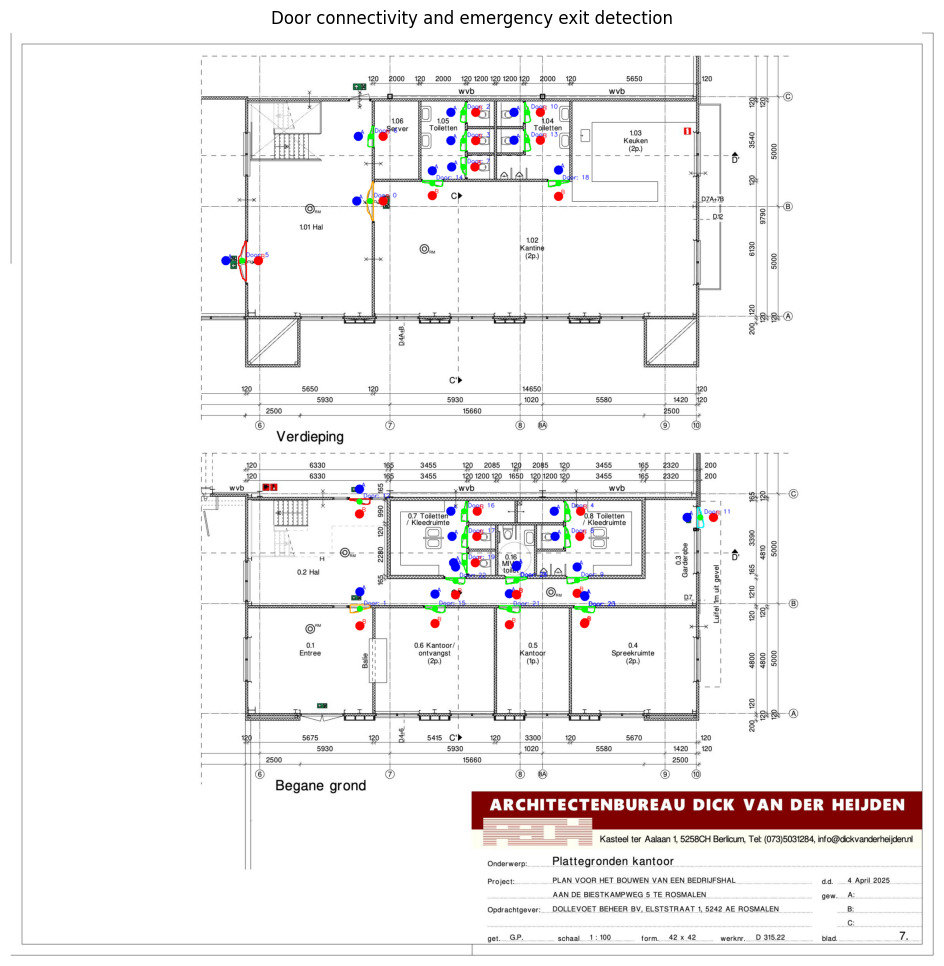

In [2]:
assign_spaces_to_doors(doors, spaces, signs)

#visualize 
test_img = image.copy() 

# visualize doors with connectivity points and emergency exit status
for door in doors:
    # redo some math to visualize connectivity points A and B
    cx, cy = door.center
    x1, y1, x2, y2 = door.bbox

    door_w = x2 - x1
    door_h = y2 - y1

     # Sample points offset from the door center to probe adjacent spaces.
    offset = max(12, int(min(door_w, door_h) * 2))

    # Orient the sample points along the door's normal direction.
    if abs(door.orientation_deg - 90.0) < 1e-6:
        point_a = (cx - offset, cy)
        point_b = (cx + offset, cy)
    else:
        point_a = (cx, cy - offset)
        point_b = (cx, cy + offset)

    # draw door polygon 
    door_pts = np.array(door.polygon, dtype=np.int32).reshape((-1, 1, 2)) 
    if (door.is_external and door.is_emergency_exit):
        cv2.polylines(test_img, [door_pts], True, (0, 0, 255), 2)
    elif (door.is_external):
        cv2.polylines(test_img, [door_pts], True, (255, 255, 0), 2)
    elif (door.is_emergency_exit):
        cv2.polylines(test_img, [door_pts], True, (0, 165, 255), 2)
    else:
        cv2.polylines(test_img, [door_pts], True, (0, 255, 0), 2)

    # draw center and test points 
    cv2.circle(test_img, door.center, 8, (0, 255, 0), -1) 
    cv2.circle(test_img, point_a, 12, (255, 0, 0), -1) 
    cv2.circle(test_img, point_b, 12, (0, 0, 255), -1) 

    # label points 
    cv2.putText(test_img, "Door: " + str(door.id), (door.center[0] + 10, door.center[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA) 
    cv2.putText(test_img, "A", (point_a[0] + 6, point_a[1] - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA) 
    cv2.putText(test_img, "B", (point_b[0] + 6, point_b[1] - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
    
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Door connectivity and emergency exit detection")
plt.axis("off")
plt.show()

## Door Duplicate Detection and Visualization

This step analyzes detected doors to identify **potential duplicate detections** or **suspicious door placements**.  
Because object detection models can occasionally detect the same door multiple times, this check helps identify those cases visually.

## Door Comparison Logic

Each door is compared with every other door.
For each pair:

1. The connected spaces are compared:
   - `space_id_a`
   - `space_id_b`

2. The Euclidean distance between door centers is calculated.

3. Based on these checks, a **color classification** is assigned:


| Color | Meaning |
|------|------|
| **Green** | Normal door (no issues detected) |
| **Red** | Likely duplicate detection (same spaces + very close) |
| **Blue** | Suspicious duplicate (same spaces but farther apart) |
| **Black** | Different spaces but unusually close together |

## Visualization

All doors are drawn on the floor plan:

- The **polygon** outlines the door detection
- A **circle** marks the door center
- A **label** displays the door ID

The color assigned to each door reflects the classification described above.

This visualization helps quickly identify:

- duplicate detections
- suspicious door placements
- potential topology errors in the detected floor plan

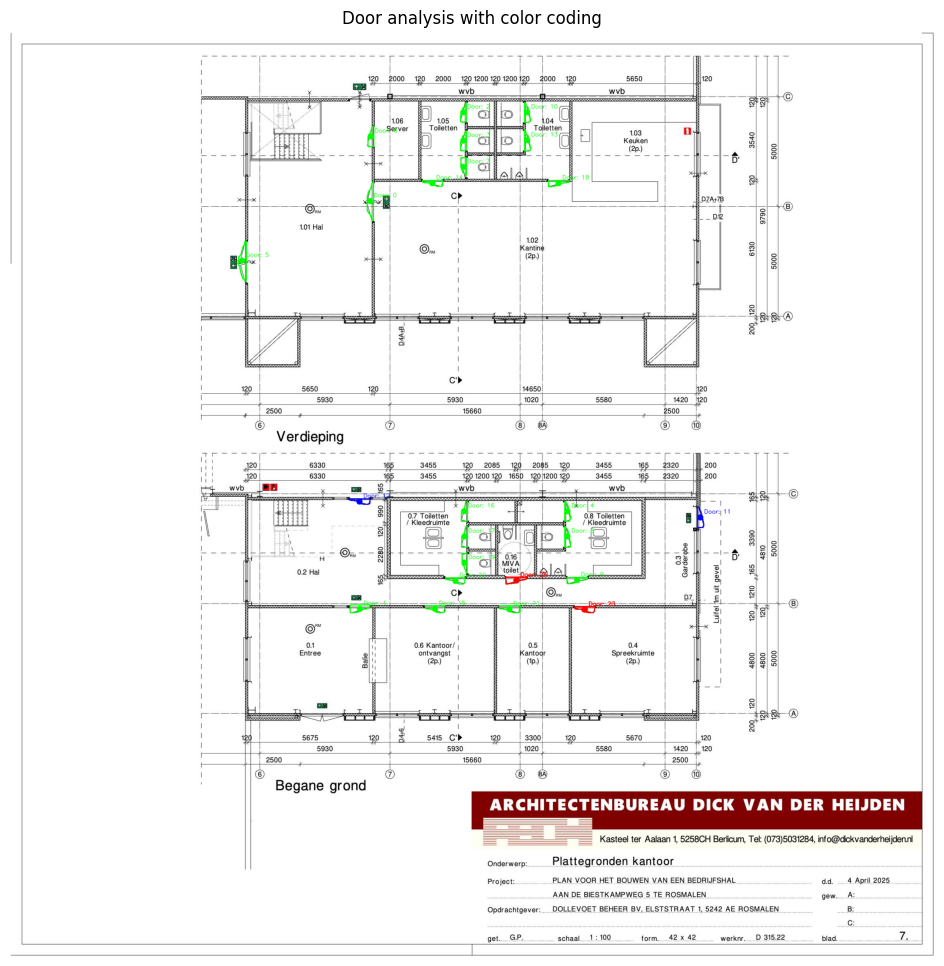

In [3]:
import math
duplicate_distance = 25

# Define colors
green = (0, 255, 0)  # nothing special
red = (0, 0, 255)    # problem: close duplicate
blue = (255, 0, 0)   # problem: far duplicate
black = (0, 0, 0)    # close but not same rooms

# Initialize all doors as green
door_colors = {door.id: green for door in doors}

# First, mark red: close duplicates
for i, d1 in enumerate(doors):
    for d2 in doors[i+1:]:
        a1 = -1 if d1.space_id_a is None else d1.space_id_a
        b1 = -1 if d1.space_id_b is None else d1.space_id_b
        a2 = -1 if d2.space_id_a is None else d2.space_id_a
        b2 = -1 if d2.space_id_b is None else d2.space_id_b

        x1, y1 = d1.center
        x2, y2 = d2.center

        if set((a1, b1)) == set((a2, b2)):
            door_colors[d1.id] = blue
            door_colors[d2.id] = blue
            if math.hypot(x2 - x1, y2 - y1) < duplicate_distance:
                door_colors[d1.id] = red
                door_colors[d2.id] = red
        else:
            if math.hypot(x2 - x1, y2 - y1) < duplicate_distance:
                door_colors[d1.id] = black
                door_colors[d2.id] = black

# Visualize
test_img = image.copy()

for door in doors:
    color = door_colors[door.id]  
    # draw door polygon
    door_pts = np.array(door.polygon, dtype=np.int32).reshape((-1, 1, 2))
    cv2.polylines(test_img, [door_pts], True, color, 2)
    # draw center
    cv2.circle(test_img, door.center, 8, color, -1)
    # label door
    cv2.putText(test_img, f"Door: {door.id}", (door.center[0] + 10, door.center[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Door analysis with color coding")
plt.axis("off")
plt.show()